# CUPED for Experimentation
- Variance Reduction using CUPED

## Create Testing Dataset

In [4]:
import numpy as np
import pandas as pd

np.random.seed(42)
N = 5000  # users per group

def generate_users(n, treatment=False):
    # Base spending tendency per user (log-normal = realistic whale distribution)
    base_spend = np.random.lognormal(mean=1.5, sigma=1.0, size=n)

    # Pre-experiment spend (30 days before): correlated with base + noise
    pre_spend = np.maximum(0, base_spend + np.random.normal(0, 8, n))

    # In-experiment spend: driven by base + noise + optional treatment effect
    treatment_effect = 1.80 if treatment else 0.0
    in_spend = np.maximum(0, base_spend * 0.75 + np.random.normal(0, 6, n) + treatment_effect)

    return pd.DataFrame({
        "user_id": [f"{'T' if treatment else 'C'}_{i:04d}" for i in range(n)],
        "group": "treatment" if treatment else "control",
        "pre_spend": pre_spend,
        "in_spend": in_spend,
    })

control   = generate_users(N, treatment=False)
treatment = generate_users(N, treatment=True)
df = pd.concat([control, treatment], ignore_index=True)

df.to_csv("experiment_data.csv", index=False)
print(df.groupby("group")[["pre_spend", "in_spend"]].describe().round(2))
print(f"\nDataset saved: {len(df):,} users")

          pre_spend                                            in_spend        \
              count  mean    std  min  25%   50%    75%    max    count  mean   
group                                                                           
control      5000.0  8.75  11.31  0.0  0.0  5.89  13.00  222.9   5000.0  6.62   
treatment    5000.0  8.73  12.10  0.0  0.0  6.02  12.98  405.9   5000.0  8.08   

                                                 
            std  min   25%   50%    75%     max  
group                                            
control    8.61  0.0  0.00  4.56   9.60  176.43  
treatment  9.72  0.0  1.31  6.26  11.75  307.12  

Dataset saved: 10,000 users


- Pre-spend means are practically even
- in-spend means favor treatment

## Run a t-test

In [5]:
import pandas as pd
from scipy import stats

df = pd.read_csv("experiment_data.csv")

ctrl = df[df.group == "control"]["in_spend"]
trt  = df[df.group == "treatment"]["in_spend"]

t_stat, p_val = stats.ttest_ind(ctrl, trt)
diff = trt.mean() - ctrl.mean()
pooled_std = df["in_spend"].std()

print("=" * 45)
print("         STANDARD T-TEST RESULTS")
print("=" * 45)
print(f"  Control mean:    ${ctrl.mean():.4f}")
print(f"  Treatment mean:  ${trt.mean():.4f}")
print(f"  Observed lift:   ${diff:.4f}")
print(f"  Variance:        {df['in_spend'].var():.2f}")
print(f"  t-statistic:     {t_stat:.4f}")
print(f"  p-value:         {p_val:.4f}")
print(f"  Significant:     {'YES ✓' if p_val < 0.05 else 'NO ✗'} (α = 0.05)")
print("=" * 45)

         STANDARD T-TEST RESULTS
  Control mean:    $6.6238
  Treatment mean:  $8.0823
  Observed lift:   $1.4584
  Variance:        84.79
  t-statistic:     -7.9437
  p-value:         0.0000
  Significant:     YES ✓ (α = 0.05)


- $1.45 lift
- Statistically Significant - treatment is effective in driving spend

## CUPED Variance Reduction

In [6]:
import pandas as pd
import numpy as np
from scipy import stats

# --- CUPED adjustment ---

# Step A: Compute theta — regression coefficient of in_spend on pre_spend
# This is how much in_spend moves per unit of pre_spend (across ALL users)
cov   = np.cov(df["in_spend"], df["pre_spend"])[0, 1]
var_x = df["pre_spend"].var()
theta = cov / var_x

# Step B: Compute the global mean of the covariate
mean_pre = df["pre_spend"].mean()

# Step C: Adjust each user's in_spend
# We subtract the part that's "explained" by their pre-experiment behavior
df["in_spend_cuped"] = df["in_spend"] - theta * (df["pre_spend"] - mean_pre)

# Step D: Compute correlation to understand how much variance we removed
rho = df["in_spend"].corr(df["pre_spend"])
variance_reduction = (1 - (1 - rho**2)) * 100  # = rho^2 * 100

# --- Run t-test on CUPED-adjusted values ---
ctrl = df[df.group == "control"]["in_spend_cuped"]
trt  = df[df.group == "treatment"]["in_spend_cuped"]

t_stat, p_val = stats.ttest_ind(ctrl, trt)
diff = trt.mean() - ctrl.mean()

print("=" * 45)
print("           CUPED RESULTS")
print("=" * 45)
print(f"  theta (θ):          {theta:.4f}")
print(f"  Correlation (ρ):    {rho:.4f}")
print(f"  Variance reduction: {rho**2 * 100:.1f}%")
print(f"  Control mean:       ${ctrl.mean():.4f}")
print(f"  Treatment mean:     ${trt.mean():.4f}")
print(f"  Observed lift:      ${diff:.4f}")
print(f"  Variance (raw):     {df['in_spend'].var():.2f}")
print(f"  Variance (CUPED):   {df['in_spend_cuped'].var():.2f}")
print(f"  t-statistic:        {t_stat:.4f}")
print(f"  p-value:            {p_val:.4f}")
print(f"  Significant:        {'YES ✓' if p_val < 0.05 else 'NO ✗'} (α = 0.05)")
print("=" * 45)

df.to_csv("experiment_data.csv", index=False)
print("\nAdjusted values saved back to CSV.")

           CUPED RESULTS
  theta (θ):          0.5524
  Correlation (ρ):    0.7027
  Variance reduction: 49.4%
  Control mean:       $6.6199
  Treatment mean:     $8.0862
  Observed lift:      $1.4662
  Variance (raw):     84.79
  Variance (CUPED):   42.92
  t-statistic:        -11.2597
  p-value:            0.0000
  Significant:        YES ✓ (α = 0.05)

Adjusted values saved back to CSV.


1. Grab the regression coefficient of how much pre-spend influences in-spend
2. What was pre-spend on average over everyone?
3. If the average pre-spend was $8 and I spent $10, the regression coefficient was 0.1, then we take $2 * 0.1 = $0.2 and subtract it from their in-spend to adjust for it.
4. Using correlation to see how much variance we reduced
5. Re-run t test

It looks like we reduced variance from 84.79 to 42.92, variance reduction of 49%!. Lift increased $0.01 and t-stat is stronger.

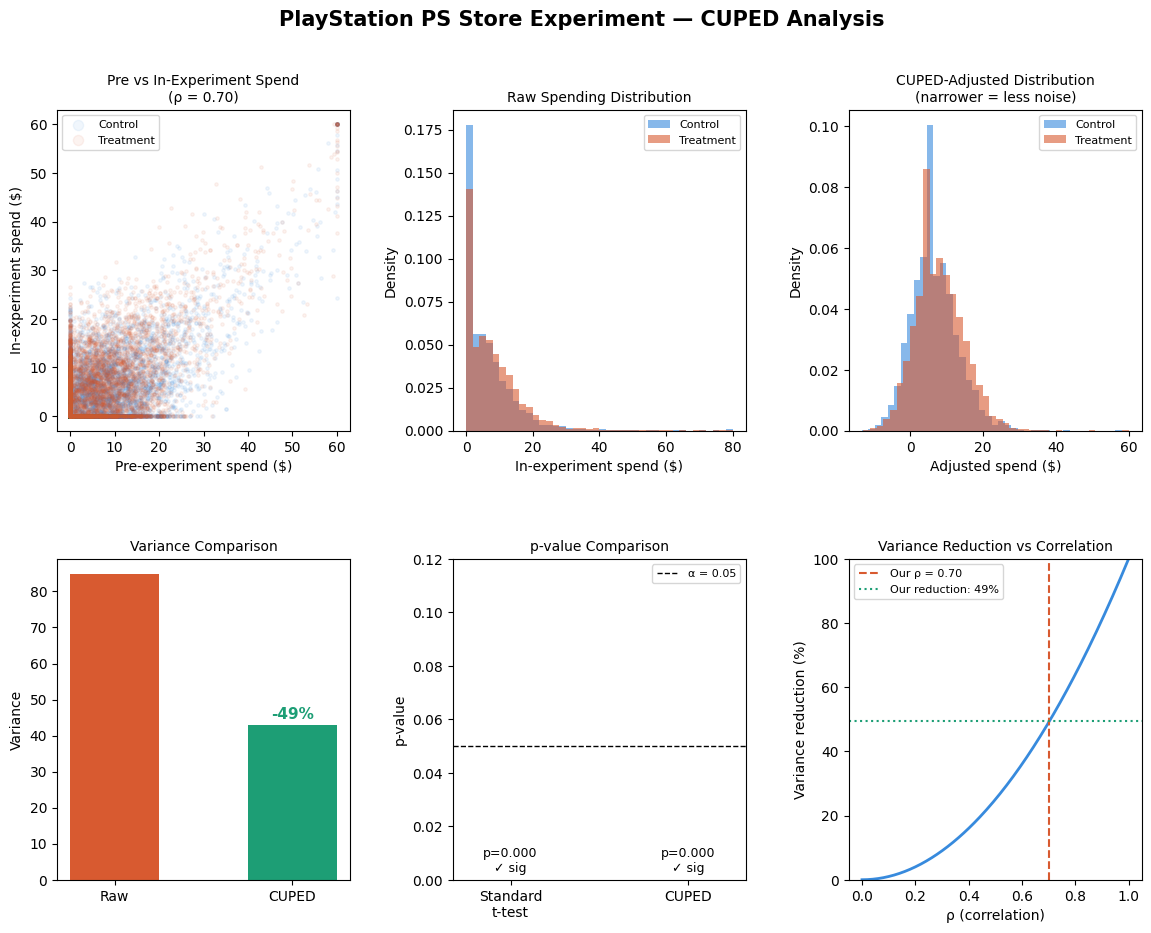

Saved: cuped_results.png


In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from scipy import stats

df = pd.read_csv("experiment_data.csv")

ctrl_raw   = df[df.group == "control"]["in_spend"]
trt_raw    = df[df.group == "treatment"]["in_spend"]
ctrl_cuped = df[df.group == "control"]["in_spend_cuped"]
trt_cuped  = df[df.group == "treatment"]["in_spend_cuped"]

_, p_raw   = stats.ttest_ind(ctrl_raw, trt_raw)
_, p_cuped = stats.ttest_ind(ctrl_cuped, trt_cuped)
rho        = df["in_spend"].corr(df["pre_spend"])

fig = plt.figure(figsize=(14, 10))
fig.suptitle("PlayStation PS Store Experiment — CUPED Analysis", fontsize=15, fontweight="bold", y=0.98)
gs = gridspec.GridSpec(2, 3, figure=fig, hspace=0.4, wspace=0.35)

BLUE, RED, GREEN = "#378ADD", "#D85A30", "#1D9E75"

# 1. Scatter: pre vs in-spend (correlation)
ax1 = fig.add_subplot(gs[0, 0])
ax1.scatter(df[df.group=="control"]["pre_spend"].clip(0,60),
            df[df.group=="control"]["in_spend"].clip(0,60),
            alpha=0.07, s=6, color=BLUE, label="Control")
ax1.scatter(df[df.group=="treatment"]["pre_spend"].clip(0,60),
            df[df.group=="treatment"]["in_spend"].clip(0,60),
            alpha=0.07, s=6, color=RED, label="Treatment")
ax1.set_title(f"Pre vs In-Experiment Spend\n(ρ = {rho:.2f})", fontsize=10)
ax1.set_xlabel("Pre-experiment spend ($)"); ax1.set_ylabel("In-experiment spend ($)")
ax1.legend(fontsize=8, markerscale=3)

# 2. Distribution: raw spending
ax2 = fig.add_subplot(gs[0, 1])
ax2.hist(ctrl_raw.clip(0, 80), bins=40, alpha=0.6, color=BLUE, label="Control", density=True)
ax2.hist(trt_raw.clip(0, 80),  bins=40, alpha=0.6, color=RED,  label="Treatment", density=True)
ax2.set_title("Raw Spending Distribution", fontsize=10)
ax2.set_xlabel("In-experiment spend ($)"); ax2.set_ylabel("Density")
ax2.legend(fontsize=8)

# 3. Distribution: CUPED-adjusted spending
ax3 = fig.add_subplot(gs[0, 2])
ax3.hist(ctrl_cuped.clip(-20, 60), bins=40, alpha=0.6, color=BLUE, label="Control", density=True)
ax3.hist(trt_cuped.clip(-20, 60),  bins=40, alpha=0.6, color=RED,  label="Treatment", density=True)
ax3.set_title("CUPED-Adjusted Distribution\n(narrower = less noise)", fontsize=10)
ax3.set_xlabel("Adjusted spend ($)"); ax3.set_ylabel("Density")
ax3.legend(fontsize=8)

# 4. Variance comparison
ax4 = fig.add_subplot(gs[1, 0])
vars_ = [df["in_spend"].var(), df["in_spend_cuped"].var()]
bars  = ax4.bar(["Raw", "CUPED"], vars_, color=[RED, GREEN], width=0.5, edgecolor="none")
ax4.set_title("Variance Comparison", fontsize=10)
ax4.set_ylabel("Variance")
reduction = (1 - vars_[1]/vars_[0]) * 100
ax4.text(1, vars_[1] + max(vars_)*0.02, f"-{reduction:.0f}%", ha="center", fontsize=11,
         color=GREEN, fontweight="bold")

# 5. P-value comparison
ax5 = fig.add_subplot(gs[1, 1])
colors = [GREEN if p < 0.05 else RED for p in [p_raw, p_cuped]]
bars   = ax5.bar(["Standard\nt-test", "CUPED"], [p_raw, p_cuped], color=colors, width=0.5, edgecolor="none")
ax5.axhline(0.05, color="black", linestyle="--", linewidth=1, label="α = 0.05")
ax5.set_title("p-value Comparison", fontsize=10)
ax5.set_ylabel("p-value")
ax5.set_ylim(0, max(p_raw, 0.12))
ax5.legend(fontsize=8)
for bar, p in zip(bars, [p_raw, p_cuped]):
    label = f"p={p:.3f}\n{'✓ sig' if p < 0.05 else '✗ not sig'}"
    ax5.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.002,
             label, ha="center", va="bottom", fontsize=9)

# 6. Variance reduction vs rho curve
ax6 = fig.add_subplot(gs[1, 2])
rho_range = np.linspace(0, 1, 200)
ax6.plot(rho_range, rho_range**2 * 100, color=BLUE, linewidth=2)
ax6.axvline(rho, color=RED, linestyle="--", linewidth=1.5, label=f"Our ρ = {rho:.2f}")
ax6.axhline(rho**2 * 100, color=GREEN, linestyle=":", linewidth=1.5,
            label=f"Our reduction: {rho**2*100:.0f}%")
ax6.set_title("Variance Reduction vs Correlation", fontsize=10)
ax6.set_xlabel("ρ (correlation)"); ax6.set_ylabel("Variance reduction (%)")
ax6.legend(fontsize=8); ax6.set_ylim(0, 100)

plt.savefig("cuped_results.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: cuped_results.png")

Variance comparison chart says it all here...